# **Pesquisa de estatística: Quatro distribuições discreta e Quatro continua**

#### _Importando as dependencias_

In [1]:
import pandas as pd                          # Manipulação dos dados
import numpy as np                           # Calculos Matmáticos
import matplotlib.pyplot as plt              # Geração de Gráficos
import seaborn as sns                        # Graficos automaticos, baseado no matplotlib
import statistics as sta                     # Biblioteca padrão do py para estatistica
from scipy import stats                      # Estastistica avançada

import warnings                              # Limpando tela de comentarios py, esconde os warnings
warnings.filterwarnings('ignore')

### **Limpeza e Preparação**

In [2]:
df_cito_mamo = pd.read_csv('../../Datasets/N1/df_cito_e_mamo_sus_siscan.csv')
cito_mamo = df_cito_mamo.drop(columns=['Unnamed: 0'])
print(cito_mamo.columns.tolist())
cito_mamo.head(10)

['estado', 'ano_mes', 'municipio', 'tipo_exame', 'valor_indicador']


,estado,ano_mes,municipio,tipo_exame,valor_indicador
0,CE,201612,ALTANEIRA,Citopatologico,33.0
1,CE,201612,ALTANEIRA,Mamografia,225.0
2,CE,201612,ANTONINA DO NORTE,Citopatologico,17.0
3,CE,201612,ARARIPE,Citopatologico,34.0
4,CE,201612,ASSARE,Citopatologico,1.0
5,CE,201612,ASSARE,Mamografia,30.0
6,CE,201612,AURORA,Mamografia,6.0
7,CE,201612,BARBALHA,Citopatologico,83.0
8,CE,201612,BARBALHA,Mamografia,2882.0
9,CE,201612,BREJO SANTO,Citopatologico,942.0


### **6. PESQUISA DE ESTATÍSTICA: Distribuições Discretas e Contínuas**

#### Introdução

As distribuições de probabilidade são modelos matemáticos que descrevem como os dados se distribuem em um espaço de possibilidades. Elas são fundamentais em estatística e são classificadas em dois tipos principais:

- **Discretas**: Aplicadas a variáveis que assumem valores inteiros (contáveis)
- **Contínuas**: Aplicadas a variáveis que podem assumir qualquer valor em um intervalo

Nesta seção, será explorado 4 distribuições discretas e 4 contínuas com aplicações práticas aos dados de saúde (citopatologia e mamografia).

## **DISTRIBUIÇÕES DISCRETAS**

#### 1. Distribuição Binomial
**O que é?**
A distribuição binomial descreve o número de sucessos em uma série de n ensaios independentes, onde cada ensaio tem probabilidade p de sucesso.

**Parâmetros:**
- n: número de tentativas
- p: probabilidade de sucesso em cada tentativa

**Fórmula:** 
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

**Aplicação ao projeto:**
Número de mulheres que realizaram mamografia em um grupo de 100 mulheres, onde a taxa de realização é 75%.

1. DISTRIBUIÇÃO BINOMIAL - Aplicação: Taxa de Realização de Mamografias
Parâmetros: n = 100 mulheres, p = 0.75 (75% de taxa)
Número de simulações: 10000

Estatísticas:
  • Média teórica (μ = n*p): 75.0
  • Média observada: 75.08
  • Desvio padrão teórico (σ = √(n*p*(1-p))): 4.33
  • Desvio padrão observado: 4.36
  • Mínimo: 57
  • Máximo: 92


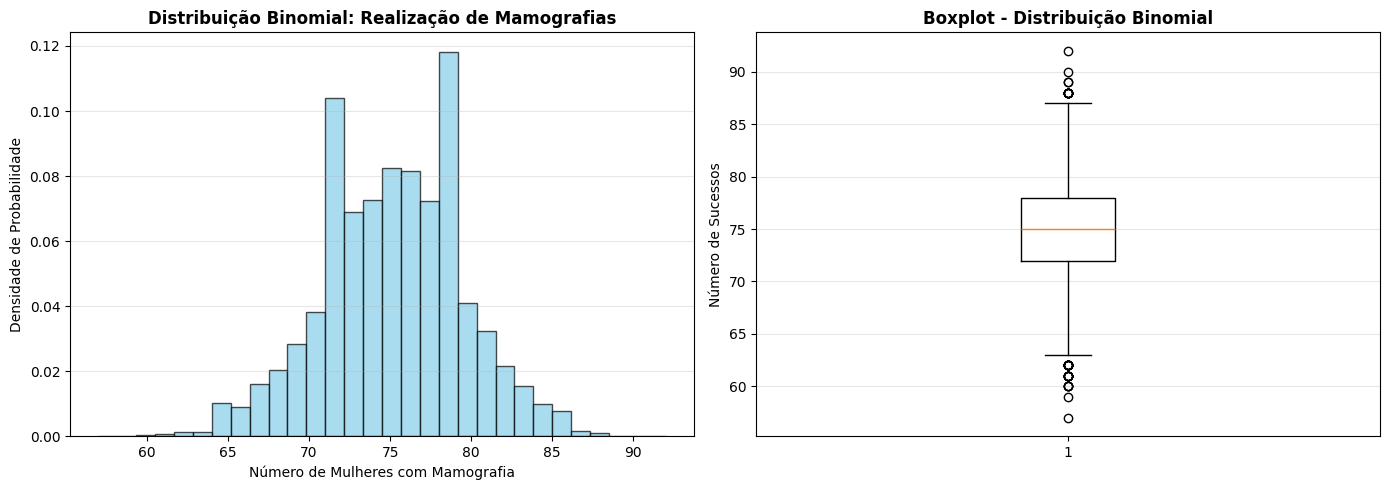

In [3]:
# Exemplo 1: Distribuição Binomial
# Simulação: 100 mulheres, probabilidade de realizar mamografia = 0.75
n = 100
p = 0.75
num_simulacoes = 10000

# Gerar dados da distribuição binomial
dados_binomial = np.random.binomial(n, p, num_simulacoes)

print("=" * 70)
print("1. DISTRIBUIÇÃO BINOMIAL - Aplicação: Taxa de Realização de Mamografias")
print("=" * 70)
print(f"Parâmetros: n = {n} mulheres, p = {p} (75% de taxa)")
print(f"Número de simulações: {num_simulacoes}")
print(f"\nEstatísticas:")
print(f"  • Média teórica (μ = n*p): {n*p}")
print(f"  • Média observada: {np.mean(dados_binomial):.2f}")
print(f"  • Desvio padrão teórico (σ = √(n*p*(1-p))): {np.sqrt(n*p*(1-p)):.2f}")
print(f"  • Desvio padrão observado: {np.std(dados_binomial):.2f}")
print(f"  • Mínimo: {np.min(dados_binomial)}")
print(f"  • Máximo: {np.max(dados_binomial)}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(dados_binomial, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('Distribuição Binomial: Realização de Mamografias', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Mulheres com Mamografia')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(dados_binomial, vert=True)
axes[1].set_title('Boxplot - Distribuição Binomial', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Sucessos')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Distribuição de Poisson
**O que é?**
A distribuição de Poisson descreve o número de eventos que ocorrem em um intervalo fixo de tempo ou espaço, quando os eventos ocorrem com taxa média constante e são independentes.

**Parâmetros:**
- λ (lambda): taxa média de eventos no intervalo

**Fórmula:**
$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}$$

**Aplicação:**
Número de casos de câncer detectados por semana em uma clínica, com média de 3 casos por semana.


2. DISTRIBUIÇÃO DE POISSON - Aplicação: Casos de Câncer por Semana
Parâmetro: λ (lambda) = 3 casos por semana
Número de semanas simuladas: 10000

Estatísticas:
  • Média teórica (μ = λ): 3
  • Média observada: 2.99
  • Desvio padrão teórico (σ = √λ): 1.73
  • Desvio padrão observado: 1.73
  • Mínimo: 0
  • Máximo: 11


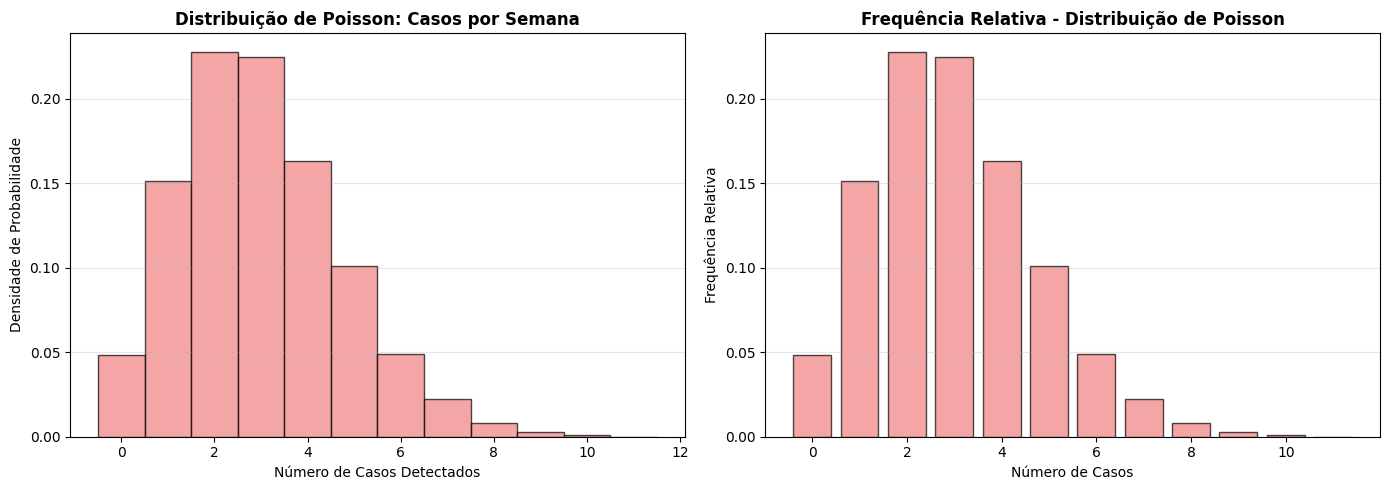

In [4]:
# Exemplo 2: Distribuição de Poisson
# Simulação: Média de 3 casos de câncer detectados por semana
lambda_param = 3
num_semanas = 10000

# Gerar dados da distribuição de Poisson
dados_poisson = np.random.poisson(lambda_param, num_semanas)

print("\n" + "=" * 70)
print("2. DISTRIBUIÇÃO DE POISSON - Aplicação: Casos de Câncer por Semana")
print("=" * 70)
print(f"Parâmetro: λ (lambda) = {lambda_param} casos por semana")
print(f"Número de semanas simuladas: {num_semanas}")
print(f"\nEstatísticas:")
print(f"  • Média teórica (μ = λ): {lambda_param}")
print(f"  • Média observada: {np.mean(dados_poisson):.2f}")
print(f"  • Desvio padrão teórico (σ = √λ): {np.sqrt(lambda_param):.2f}")
print(f"  • Desvio padrão observado: {np.std(dados_poisson):.2f}")
print(f"  • Mínimo: {np.min(dados_poisson)}")
print(f"  • Máximo: {np.max(dados_poisson)}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(dados_poisson, bins=range(0, max(dados_poisson)+2), density=True, alpha=0.7, 
             color='lightcoral', edgecolor='black', align='left')
axes[0].set_title('Distribuição de Poisson: Casos por Semana', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Casos Detectados')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de frequência
unique, counts = np.unique(dados_poisson, return_counts=True)
axes[1].bar(unique, counts/num_semanas, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_title('Frequência Relativa - Distribuição de Poisson', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Casos')
axes[1].set_ylabel('Frequência Relativa')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Distribuição Hipergeométrica
**O que é?**
A distribuição hipergeométrica descreve o número de sucessos ao extrair n amostras sem reposição de uma população finita contendo K sucessos.

**Parâmetros:**
- N: tamanho da população total
- K: número de sucessos na população
- n: número de amostras

**Fórmula:**
$$P(X = k) = \frac{\binom{K}{k}\binom{N-K}{n-k}}{\binom{N}{n}}$$

**Aplicação:**
Em um lote de 1000 amostras de citopatologia, 150 foram positivas. Se selecionarmos 50 amostras aleatoriamente, qual é a probabilidade de encontrar exatamente 8 positivas?


3. DISTRIBUIÇÃO HIPERGEOMÉTRICA - Aplicação: Amostras Positivas em Lote
Parâmetros: N = 1000 (total), K = 150 (positivas), n = 50 (amostra)
Número de simulações: 10000

Estatísticas:
  • Média teórica (μ = n*K/N): 7.50
  • Média observada: 7.52
  • Desvio padrão teórico: 2.46
  • Desvio padrão observado: 2.48
  • Mínimo: 0
  • Máximo: 19


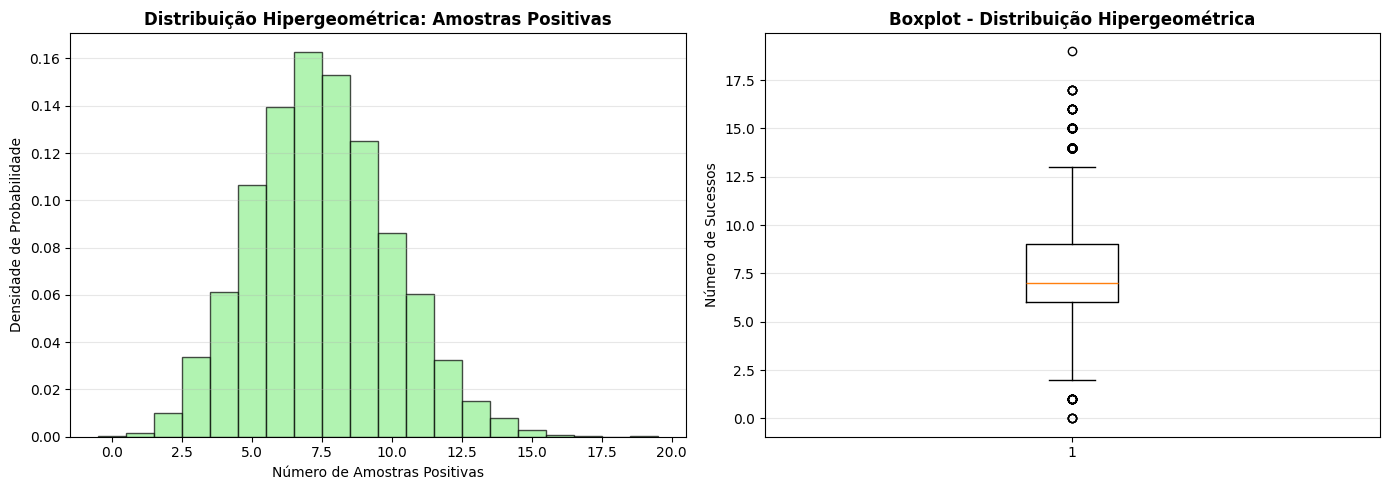

In [5]:
# Exemplo 3: Distribuição Hipergeométrica
# Parâmetros: 1000 amostras totais, 150 positivas, extrair 50 amostras
N = 1000      # população total
K = 150       # sucessos na população
n = 50        # amostras extraídas
num_simulacoes = 10000

# Gerar dados da distribuição hipergeométrica
dados_hipergeom = np.random.hypergeometric(K, N-K, n, num_simulacoes)

print("\n" + "=" * 70)
print("3. DISTRIBUIÇÃO HIPERGEOMÉTRICA - Aplicação: Amostras Positivas em Lote")
print("=" * 70)
print(f"Parâmetros: N = {N} (total), K = {K} (positivas), n = {n} (amostra)")
print(f"Número de simulações: {num_simulacoes}")
print(f"\nEstatísticas:")
media_teorica = n * (K / N)
variancia_teorica = n * (K/N) * ((N-K)/N) * ((N-n)/(N-1))
print(f"  • Média teórica (μ = n*K/N): {media_teorica:.2f}")
print(f"  • Média observada: {np.mean(dados_hipergeom):.2f}")
print(f"  • Desvio padrão teórico: {np.sqrt(variancia_teorica):.2f}")
print(f"  • Desvio padrão observado: {np.std(dados_hipergeom):.2f}")
print(f"  • Mínimo: {np.min(dados_hipergeom)}")
print(f"  • Máximo: {np.max(dados_hipergeom)}")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(dados_hipergeom, bins=range(min(dados_hipergeom), max(dados_hipergeom)+2), 
             density=True, alpha=0.7, color='lightgreen', edgecolor='black', align='left')
axes[0].set_title('Distribuição Hipergeométrica: Amostras Positivas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Número de Amostras Positivas')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].grid(axis='y', alpha=0.3)

# Boxplot
axes[1].boxplot(dados_hipergeom, vert=True)
axes[1].set_title('Boxplot - Distribuição Hipergeométrica', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Sucessos')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Distribuição Multinomial
**O que é?**
A distribuição multinomial é uma generalização da distribuição binomial para mais de 2 categorias. Descreve a probabilidade de observar uma combinação específica de resultados quando há múltiplas categorias possíveis.

**Parâmetros:**
- n: número total de tentativas
- p₁, p₂, ..., pₖ: probabilidades para cada categoria (∑pᵢ = 1)

**Fórmula:**
$$P(X_1 = n_1, X_2 = n_2, ..., X_k = n_k) = \frac{n!}{n_1! n_2! ... n_k!} p_1^{n_1} p_2^{n_2} ... p_k^{n_k}$$

**Aplicação:**
Classificação de 1000 mulheres em 3 grupos etários: 25-40 (30%), 41-55 (50%), 56-64 (20%)


4. DISTRIBUIÇÃO MULTINOMIAL - Aplicação: Distribuição por Faixa Etária
Parâmetros: n = 1000 mulheres, probabilidades = [0.3, 0.5, 0.2]
Categorias: 25-40 anos (30%), 41-55 anos (50%), 56-64 anos (20%)
Número de simulações: 10000

Estatísticas por Categoria:

1. 25-40 anos (p = 0.3):
  • Média teórica (μ = n*p): 300.0
  • Média observada: 300.02
  • Desvio padrão teórico: 14.49
  • Desvio padrão observado: 14.65

2. 41-55 anos (p = 0.5):
  • Média teórica (μ = n*p): 500.0
  • Média observada: 499.73
  • Desvio padrão teórico: 15.81
  • Desvio padrão observado: 15.85

3. 56-64 anos (p = 0.2):
  • Média teórica (μ = n*p): 200.0
  • Média observada: 200.25
  • Desvio padrão teórico: 12.65
  • Desvio padrão observado: 12.58


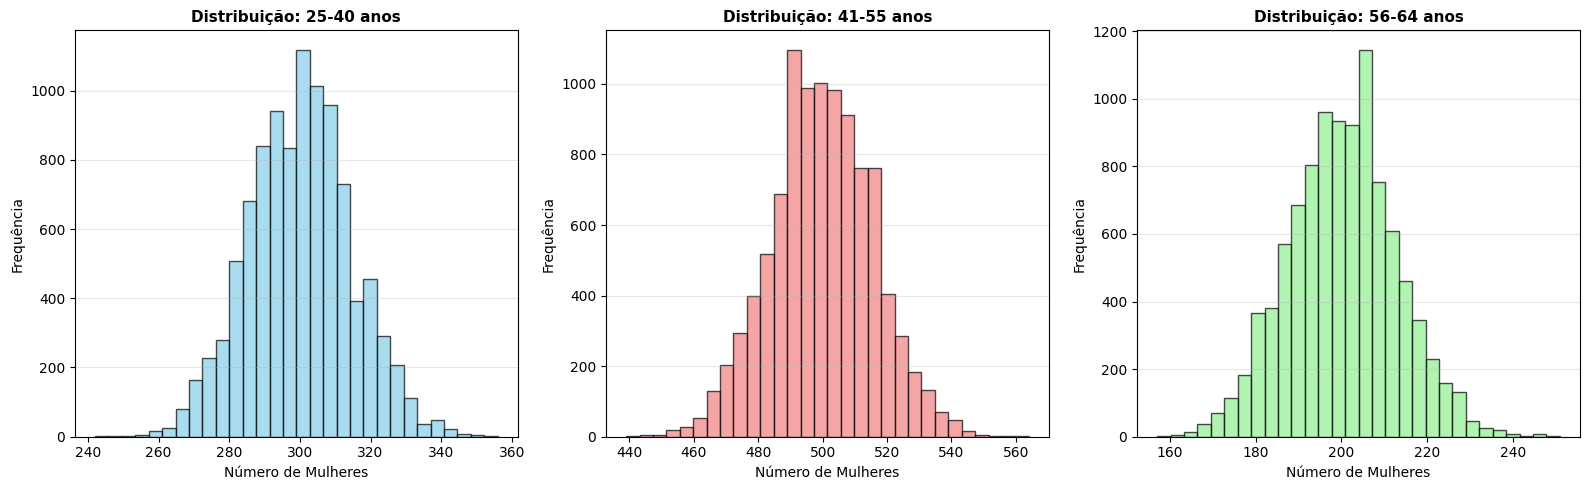


CORRELAÇÃO ENTRE CATEGORIAS (Multinomial)
Matriz de Correlação:
  25-40 anos vs 25-40 anos: 1.000
  25-40 anos vs 41-55 anos: -0.662
  25-40 anos vs 56-64 anos: -0.329
  41-55 anos vs 25-40 anos: -0.662
  41-55 anos vs 41-55 anos: 1.000
  41-55 anos vs 56-64 anos: -0.489
  56-64 anos vs 25-40 anos: -0.329
  56-64 anos vs 41-55 anos: -0.489
  56-64 anos vs 56-64 anos: 1.000


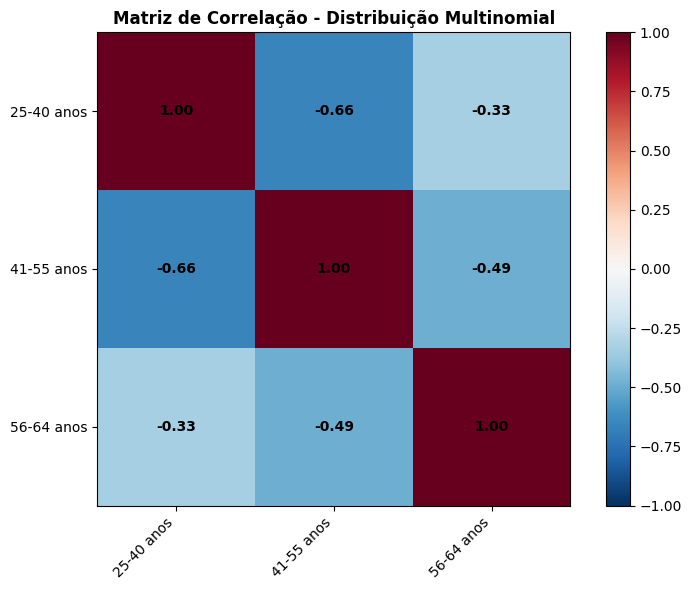

In [6]:
# Exemplo 4: Distribuição Multinomial
# Parâmetros: 1000 mulheres em 3 grupos etários
n = 1000
p = [0.30, 0.50, 0.20]  # proporções dos grupos: 25-40, 41-55, 56-64
num_simulacoes = 10000

# Gerar dados da distribuição multinomial
dados_multinomial = np.array([np.random.multinomial(n, p) for _ in range(num_simulacoes)])

print("\n" + "=" * 70)
print("4. DISTRIBUIÇÃO MULTINOMIAL - Aplicação: Distribuição por Faixa Etária")
print("=" * 70)
print(f"Parâmetros: n = {n} mulheres, probabilidades = {p}")
print(f"Categorias: 25-40 anos (30%), 41-55 anos (50%), 56-64 anos (20%)")
print(f"Número de simulações: {num_simulacoes}")
print(f"\nEstatísticas por Categoria:")

categorias = ['25-40 anos', '41-55 anos', '56-64 anos']
for i, cat in enumerate(categorias):
    print(f"\n{i+1}. {cat} (p = {p[i]}):")
    print(f"  • Média teórica (μ = n*p): {n*p[i]:.1f}")
    print(f"  • Média observada: {np.mean(dados_multinomial[:, i]):.2f}")
    print(f"  • Desvio padrão teórico: {np.sqrt(n*p[i]*(1-p[i])):.2f}")
    print(f"  • Desvio padrão observado: {np.std(dados_multinomial[:, i]):.2f}")

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, cat in enumerate(categorias):
    axes[i].hist(dados_multinomial[:, i], bins=30, alpha=0.7, 
                 color=['skyblue', 'lightcoral', 'lightgreen'][i], edgecolor='black')
    axes[i].set_title(f'Distribuição: {cat}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Número de Mulheres')
    axes[i].set_ylabel('Frequência')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de correlação entre as categorias
print("\n" + "=" * 70)
print("CORRELAÇÃO ENTRE CATEGORIAS (Multinomial)")
print("=" * 70)
correlacao = np.corrcoef(dados_multinomial.T)
print("Matriz de Correlação:")
for i in range(3):
    for j in range(3):
        print(f"  {categorias[i]} vs {categorias[j]}: {correlacao[i, j]:.3f}")
        
# Visualizar correlação
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(correlacao, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(categorias, rotation=45, ha='right')
ax.set_yticklabels(categorias)
ax.set_title('Matriz de Correlação - Distribuição Multinomial', fontweight='bold')

for i in range(3):
    for j in range(3):
        text = ax.text(j, i, f'{correlacao[i, j]:.2f}', ha="center", va="center", color="black", fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

## **DISTRIBUIÇÕES CONTÍNUAS**

#### 1. Distribuição Normal (Gaussiana)
**O que é?**
A distribuição normal é a mais importante em estatística. Descreve dados que se concentram em torno de uma média, com dispersão simétrica. É usada em práticas estatísticas por sua importância teórica e prática.

**Parâmetros:**
- μ (mu): média
- σ (sigma): desvio padrão

**Fórmula:**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2}(\frac{x-\mu}{\sigma})^2}$$

**Aplicação:**
Distribuição dos valores de indicadores de mamografia em um estado, com média 500 exames e desvio padrão 100.

1. DISTRIBUIÇÃO NORMAL - Aplicação: Indicadores de Mamografia
Parâmetros: μ = 500, σ = 100
Número de amostras: 10000

Estatísticas:
  • Média teórica (μ): 500
  • Média observada: 499.48
  • Desvio padrão teórico (σ): 100
  • Desvio padrão observado: 98.43
  • Mínimo: 104.77
  • Máximo: 853.77
  • Curtose: 0.0166
  • Assimetria: 0.0324

Teste de Shapiro-Wilk: p-valor = 0.272641


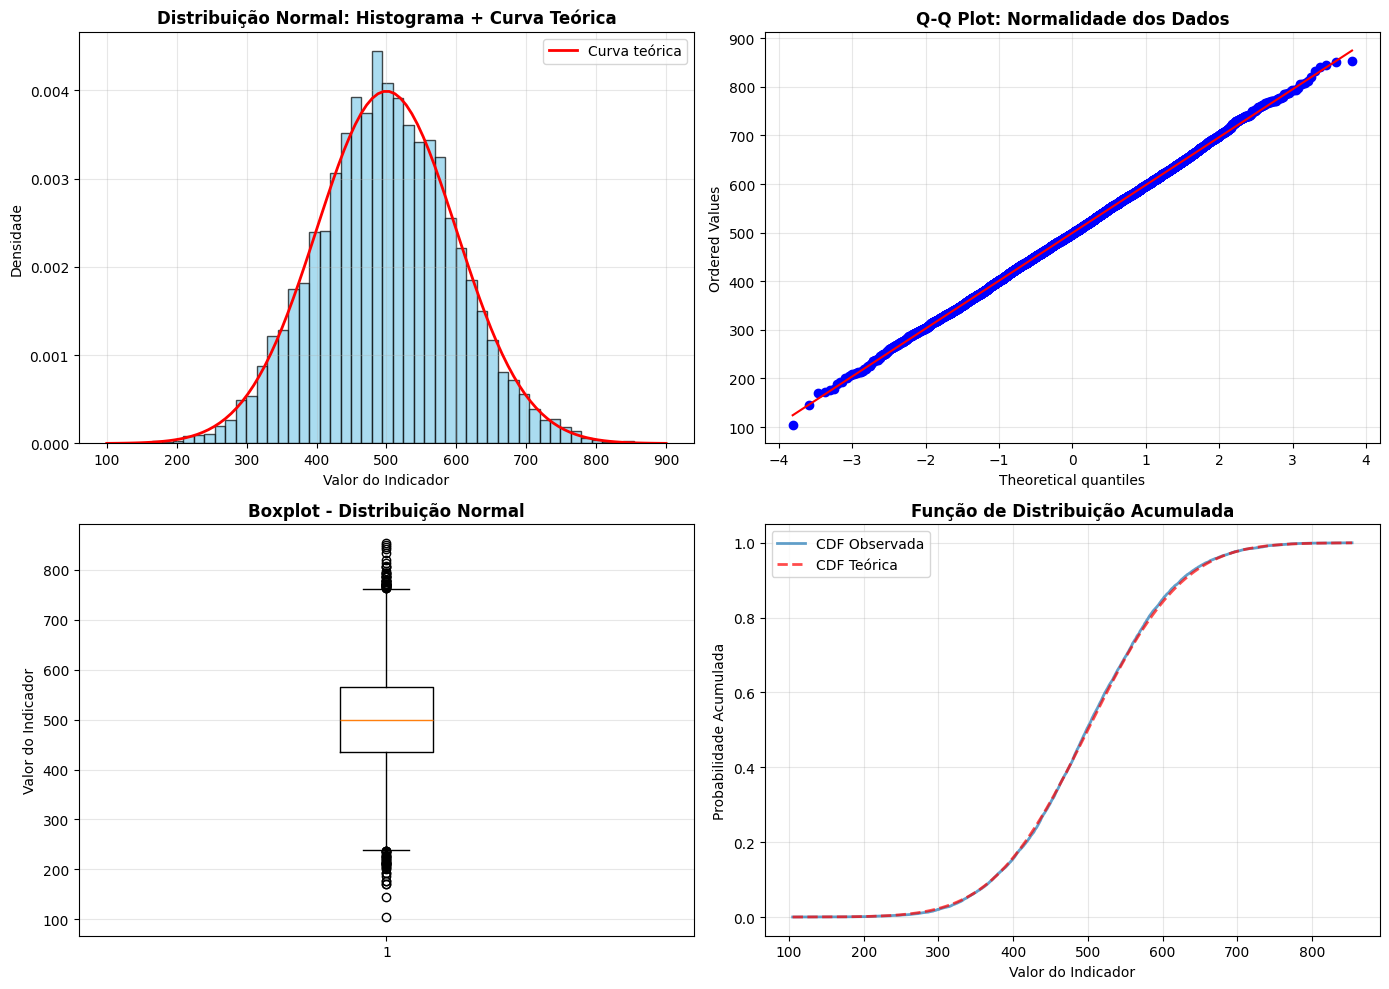

In [7]:
# Exemplo 1: Distribuição Normal
# Parâmetros: média 500, desvio padrão 100
mu = 500
sigma = 100
n_amostras = 10000

# Gerar dados da distribuição normal
dados_normal = np.random.normal(mu, sigma, n_amostras)

print("=" * 70)
print("1. DISTRIBUIÇÃO NORMAL - Aplicação: Indicadores de Mamografia")
print("=" * 70)
print(f"Parâmetros: μ = {mu}, σ = {sigma}")
print(f"Número de amostras: {n_amostras}")
print(f"\nEstatísticas:")
print(f"  • Média teórica (μ): {mu}")
print(f"  • Média observada: {np.mean(dados_normal):.2f}")
print(f"  • Desvio padrão teórico (σ): {sigma}")
print(f"  • Desvio padrão observado: {np.std(dados_normal):.2f}")
print(f"  • Mínimo: {np.min(dados_normal):.2f}")
print(f"  • Máximo: {np.max(dados_normal):.2f}")
print(f"  • Curtose: {stats.kurtosis(dados_normal):.4f}")
print(f"  • Assimetria: {stats.skew(dados_normal):.4f}")

# Teste de normalidade (Shapiro-Wilk)
amostra_teste = np.random.choice(dados_normal, 5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(amostra_teste)
print(f"\nTeste de Shapiro-Wilk: p-valor = {shapiro_p:.6f}")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma com curva teórica
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
axes[0, 0].hist(dados_normal, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Curva teórica')
axes[0, 0].set_title('Distribuição Normal: Histograma + Curva Teórica', fontweight='bold')
axes[0, 0].set_xlabel('Valor do Indicador')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Q-Q Plot
stats.probplot(dados_normal, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot: Normalidade dos Dados', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Box plot
axes[1, 0].boxplot(dados_normal, vert=True)
axes[1, 0].set_title('Boxplot - Distribuição Normal', fontweight='bold')
axes[1, 0].set_ylabel('Valor do Indicador')
axes[1, 0].grid(axis='y', alpha=0.3)

# CDF teórica vs observada
sorted_data = np.sort(dados_normal)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = stats.norm.cdf(sorted_data, mu, sigma)
axes[1, 1].plot(sorted_data, empirical_cdf, alpha=0.7, label='CDF Observada', linewidth=2)
axes[1, 1].plot(sorted_data, theoretical_cdf, 'r--', alpha=0.7, label='CDF Teórica', linewidth=2)
axes[1, 1].set_title('Função de Distribuição Acumulada', fontweight='bold')
axes[1, 1].set_xlabel('Valor do Indicador')
axes[1, 1].set_ylabel('Probabilidade Acumulada')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Distribuição Exponencial
**O que é?**
A distribuição exponencial descreve o tempo entre eventos sucessivos em um processo de Poisson. É amplamente utilizada em análises de sobrevivência e tempo até falha.

**Parâmetros:**
- λ (lambda): taxa (1/λ é a média)

**Fórmula:**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Aplicação:**
Tempo (em meses) até o próximo diagnóstico de câncer em uma população, com taxa média de 2 casos por ano (λ = 1/6).


2. DISTRIBUIÇÃO EXPONENCIAL - Aplicação: Tempo até Próximo Diagnóstico
Parâmetro: λ = 0.1667 (média = 6.0 meses)
Número de amostras: 10000

Estatísticas:
  • Média teórica (1/λ): 6.00 meses
  • Média observada: 6.05 meses
  • Desvio padrão teórico: 6.00 meses
  • Desvio padrão observado: 6.09 meses
  • Mínimo: 0.00 meses
  • Máximo: 57.24 meses
  • Mediana: 4.19 meses


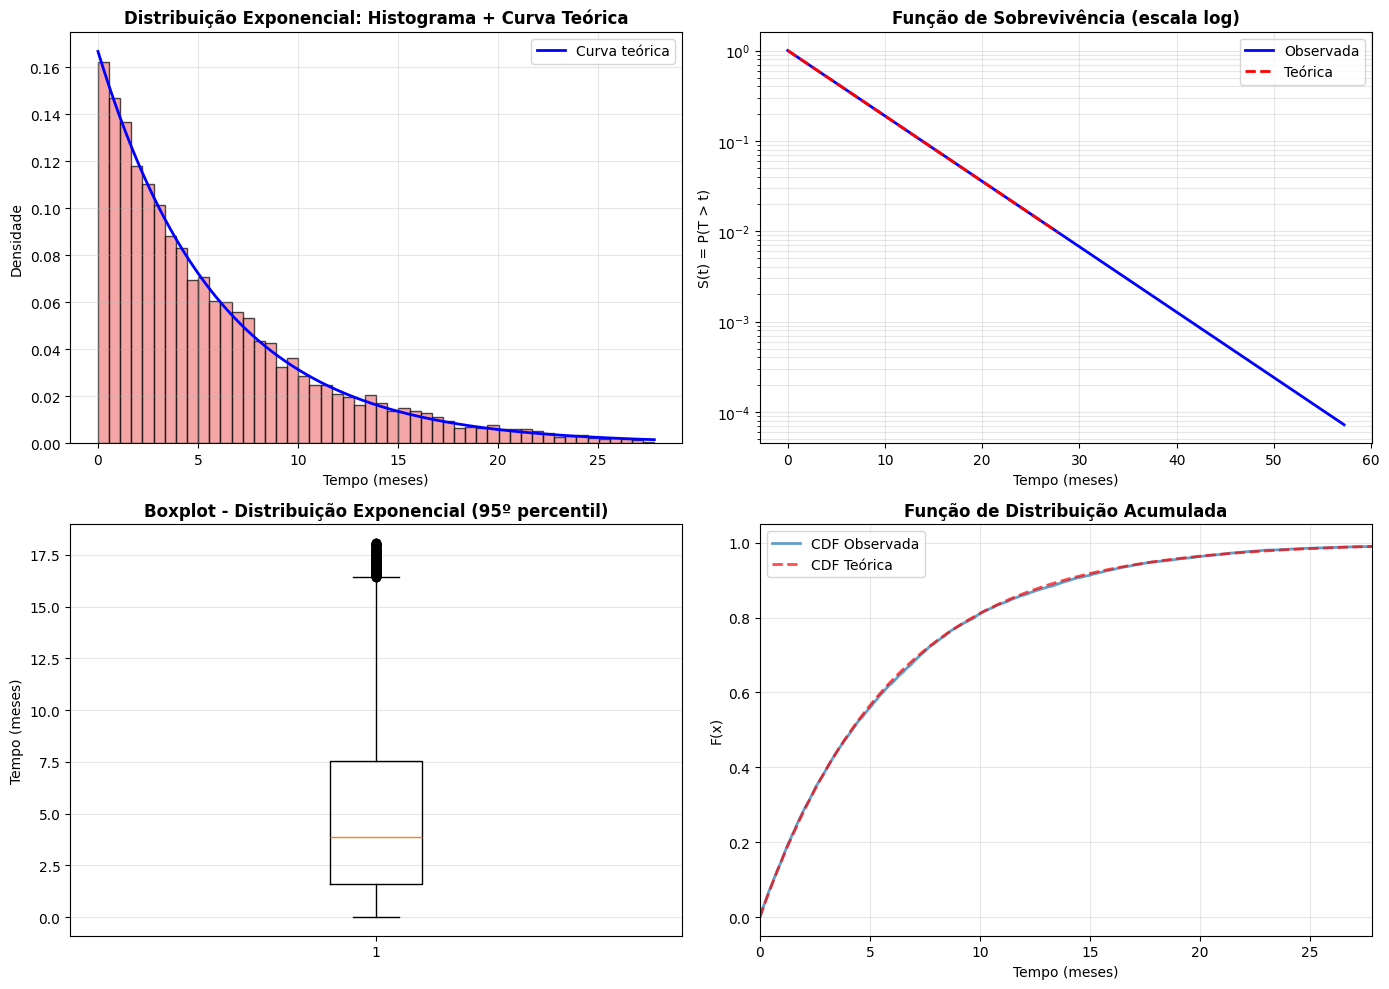

In [8]:
# Exemplo 2: Distribuição Exponencial
# Parâmetros: taxa λ = 1/6 (média = 6 meses)
lambda_exp = 1/6  # Um caso a cada 6 meses em média
n_amostras = 10000

# Gerar dados da distribuição exponencial
dados_exp = np.random.exponential(1/lambda_exp, n_amostras)

print("\n" + "=" * 70)
print("2. DISTRIBUIÇÃO EXPONENCIAL - Aplicação: Tempo até Próximo Diagnóstico")
print("=" * 70)
print(f"Parâmetro: λ = {lambda_exp:.4f} (média = {1/lambda_exp:.1f} meses)")
print(f"Número de amostras: {n_amostras}")
print(f"\nEstatísticas:")
print(f"  • Média teórica (1/λ): {1/lambda_exp:.2f} meses")
print(f"  • Média observada: {np.mean(dados_exp):.2f} meses")
print(f"  • Desvio padrão teórico: {1/lambda_exp:.2f} meses")
print(f"  • Desvio padrão observado: {np.std(dados_exp):.2f} meses")
print(f"  • Mínimo: {np.min(dados_exp):.2f} meses")
print(f"  • Máximo: {np.max(dados_exp):.2f} meses")
print(f"  • Mediana: {np.median(dados_exp):.2f} meses")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma com curva teórica
x = np.linspace(0, np.percentile(dados_exp, 99), 1000)
axes[0, 0].hist(dados_exp, bins=50, density=True, alpha=0.7, color='lightcoral', edgecolor='black', range=(0, np.percentile(dados_exp, 99)))
axes[0, 0].plot(x, lambda_exp * np.exp(-lambda_exp * x), 'b-', linewidth=2, label='Curva teórica')
axes[0, 0].set_title('Distribuição Exponencial: Histograma + Curva Teórica', fontweight='bold')
axes[0, 0].set_xlabel('Tempo (meses)')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Função de sobrevivência (complemento da CDF)
sorted_data = np.sort(dados_exp)
survival_function = 1 - stats.expon.cdf(sorted_data, scale=1/lambda_exp)
axes[0, 1].semilogy(sorted_data, survival_function, 'b-', linewidth=2, label='Observada')
axes[0, 1].semilogy(x, np.exp(-lambda_exp * x), 'r--', linewidth=2, label='Teórica')
axes[0, 1].set_title('Função de Sobrevivência (escala log)', fontweight='bold')
axes[0, 1].set_xlabel('Tempo (meses)')
axes[0, 1].set_ylabel('S(t) = P(T > t)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, which='both')

# Box plot
bp = axes[1, 0].boxplot([dados_exp[dados_exp <= np.percentile(dados_exp, 95)]], vert=True)
axes[1, 0].set_title('Boxplot - Distribuição Exponencial (95º percentil)', fontweight='bold')
axes[1, 0].set_ylabel('Tempo (meses)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Acumulada (CDF)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = stats.expon.cdf(sorted_data, scale=1/lambda_exp)
axes[1, 1].plot(sorted_data, empirical_cdf, alpha=0.7, label='CDF Observada', linewidth=2, linestyle='-')
axes[1, 1].plot(sorted_data, theoretical_cdf, 'r--', alpha=0.7, label='CDF Teórica', linewidth=2)
axes[1, 1].set_xlim(0, np.percentile(dados_exp, 99))
axes[1, 1].set_title('Função de Distribuição Acumulada', fontweight='bold')
axes[1, 1].set_xlabel('Tempo (meses)')
axes[1, 1].set_ylabel('F(x)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Distribuição Uniforme
**O que é?**
A distribuição uniforme descreve uma situação onde todos os valores em um intervalo [a, b] têm igual probabilidade de ocorrer. É frequentemente usada como distribuição nula (hipótese de não efeito).

**Parâmetros:**
- a: limite inferior
- b: limite superior

**Fórmula:**
$$f(x) = \frac{1}{b-a}, \quad a \leq x \leq b$$

**Aplicação:**
Simulação de cobertura de rastreamento em municípios, assumindo que qualquer município pode ter cobertura entre 0% e 100% com igual probabilidade (cenário sem informação prévia).


3. DISTRIBUIÇÃO UNIFORME - Aplicação: Cobertura de Rastreamento
Parâmetros: a = 0%, b = 100%
Número de amostras: 10000

Estatísticas:
  • Média teórica ((a+b)/2): 50.00%
  • Média observada: 49.45%
  • Desvio padrão teórico (√((b-a)²/12)): 28.87%
  • Desvio padrão observado: 28.77%
  • Mínimo: 0.00%
  • Máximo: 99.98%
  • Mediana: 49.45%


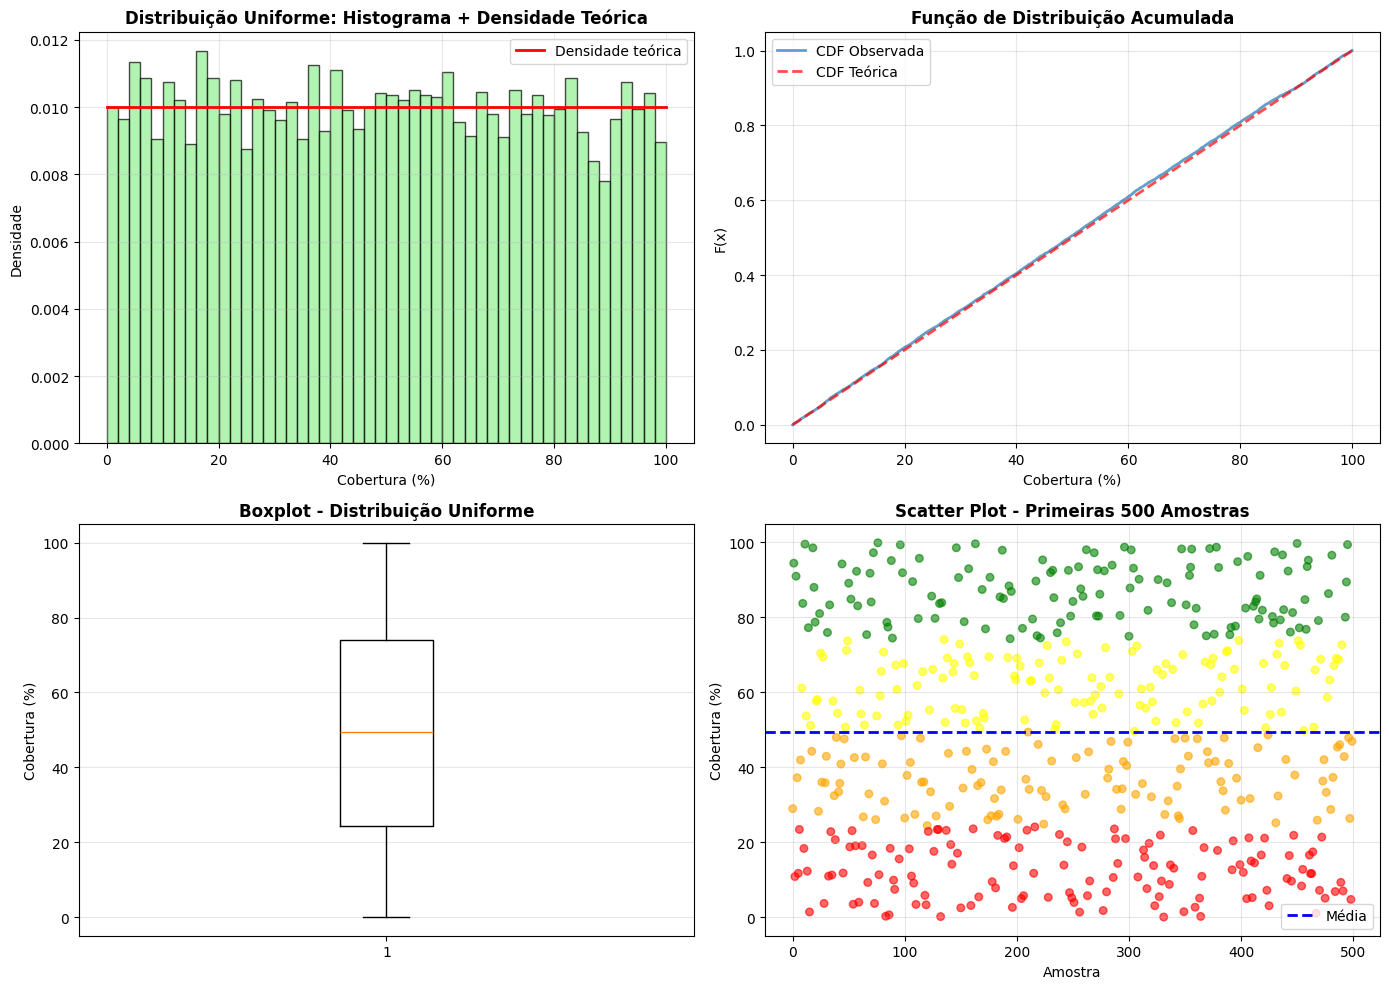

In [9]:
# Exemplo 3: Distribuição Uniforme
# Parâmetros: cobertura entre 0% e 100%
a = 0
b = 100
n_amostras = 10000

# Gerar dados da distribuição uniforme
dados_uniforme = np.random.uniform(a, b, n_amostras)

print("\n" + "=" * 70)
print("3. DISTRIBUIÇÃO UNIFORME - Aplicação: Cobertura de Rastreamento")
print("=" * 70)
print(f"Parâmetros: a = {a}%, b = {b}%")
print(f"Número de amostras: {n_amostras}")
print(f"\nEstatísticas:")
print(f"  • Média teórica ((a+b)/2): {(a+b)/2:.2f}%")
print(f"  • Média observada: {np.mean(dados_uniforme):.2f}%")
print(f"  • Desvio padrão teórico (√((b-a)²/12)): {np.sqrt((b-a)**2/12):.2f}%")
print(f"  • Desvio padrão observado: {np.std(dados_uniforme):.2f}%")
print(f"  • Mínimo: {np.min(dados_uniforme):.2f}%")
print(f"  • Máximo: {np.max(dados_uniforme):.2f}%")
print(f"  • Mediana: {np.median(dados_uniforme):.2f}%")

# Visualização
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma com curva teórica
axes[0, 0].hist(dados_uniforme, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
x = np.linspace(a, b, 100)
axes[0, 0].plot(x, np.ones_like(x)/(b-a), 'r-', linewidth=2, label='Densidade teórica')
axes[0, 0].set_title('Distribuição Uniforme: Histograma + Densidade Teórica', fontweight='bold')
axes[0, 0].set_xlabel('Cobertura (%)')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# CDF teórica vs observada
sorted_data = np.sort(dados_uniforme)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = (sorted_data - a) / (b - a)
axes[0, 1].plot(sorted_data, empirical_cdf, alpha=0.7, label='CDF Observada', linewidth=2)
axes[0, 1].plot(sorted_data, theoretical_cdf, 'r--', alpha=0.7, label='CDF Teórica', linewidth=2)
axes[0, 1].set_title('Função de Distribuição Acumulada', fontweight='bold')
axes[0, 1].set_xlabel('Cobertura (%)')
axes[0, 1].set_ylabel('F(x)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Box plot
axes[1, 0].boxplot(dados_uniforme, vert=True)
axes[1, 0].set_title('Boxplot - Distribuição Uniforme', fontweight='bold')
axes[1, 0].set_ylabel('Cobertura (%)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Gráfico de dispersão por quartis
quartis = np.percentile(dados_uniforme, [25, 50, 75])
cores = []
for val in dados_uniforme[:500]:
    if val <= quartis[0]:
        cores.append('red')
    elif val <= quartis[1]:
        cores.append('orange')
    elif val <= quartis[2]:
        cores.append('yellow')
    else:
        cores.append('green')

axes[1, 1].scatter(range(500), dados_uniforme[:500], c=cores, alpha=0.6, s=30)
axes[1, 1].axhline(y=np.mean(dados_uniforme), color='blue', linestyle='--', linewidth=2, label='Média')
axes[1, 1].set_title('Scatter Plot - Primeiras 500 Amostras', fontweight='bold')
axes[1, 1].set_xlabel('Amostra')
axes[1, 1].set_ylabel('Cobertura (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4. Distribuição Log-normal
**O que é?**
A distribuição log-normal descreve dados cujo logaritmo segue uma distribuição normal. É frequentemente usada para modelar dados assimétricos positivos, como tempo de sobrevivência, tamanho de partículas e dados biológicos.

**Parâmetros:**
- μ: média do logaritmo
- σ: desvio padrão do logaritmo

**Fórmula:**
$$f(x) = \frac{1}{x\sigma\sqrt{2\pi}} e^{-\frac{(\ln x - \mu)^2}{2\sigma^2}}, \quad x > 0$$

**Aplicação:**
Modelar o tempo de progressão (em meses) de pré-cancerosas lesões até câncer diagnosticado, que tipicamente mostra assimetria positiva.


4. DISTRIBUIÇÃO LOG-NORMAL - Aplicação: Tempo de Progressão de Lesão
Parâmetros: μ = 3.5, σ = 0.8
Número de amostras: 10000

Estatísticas:
  • Média teórica (exp(μ + σ²/2)): 45.60 meses
  • Média observada: 45.61 meses
  • Desvio padrão teórico: 43.18 meses
  • Desvio padrão observado: 43.75 meses
  • Mínimo: 1.32 meses
  • Máximo: 951.94 meses
  • Mediana teórica (exp(μ)): 33.12 meses
  • Mediana observada: 32.88 meses
  • Assimetria: 4.1170


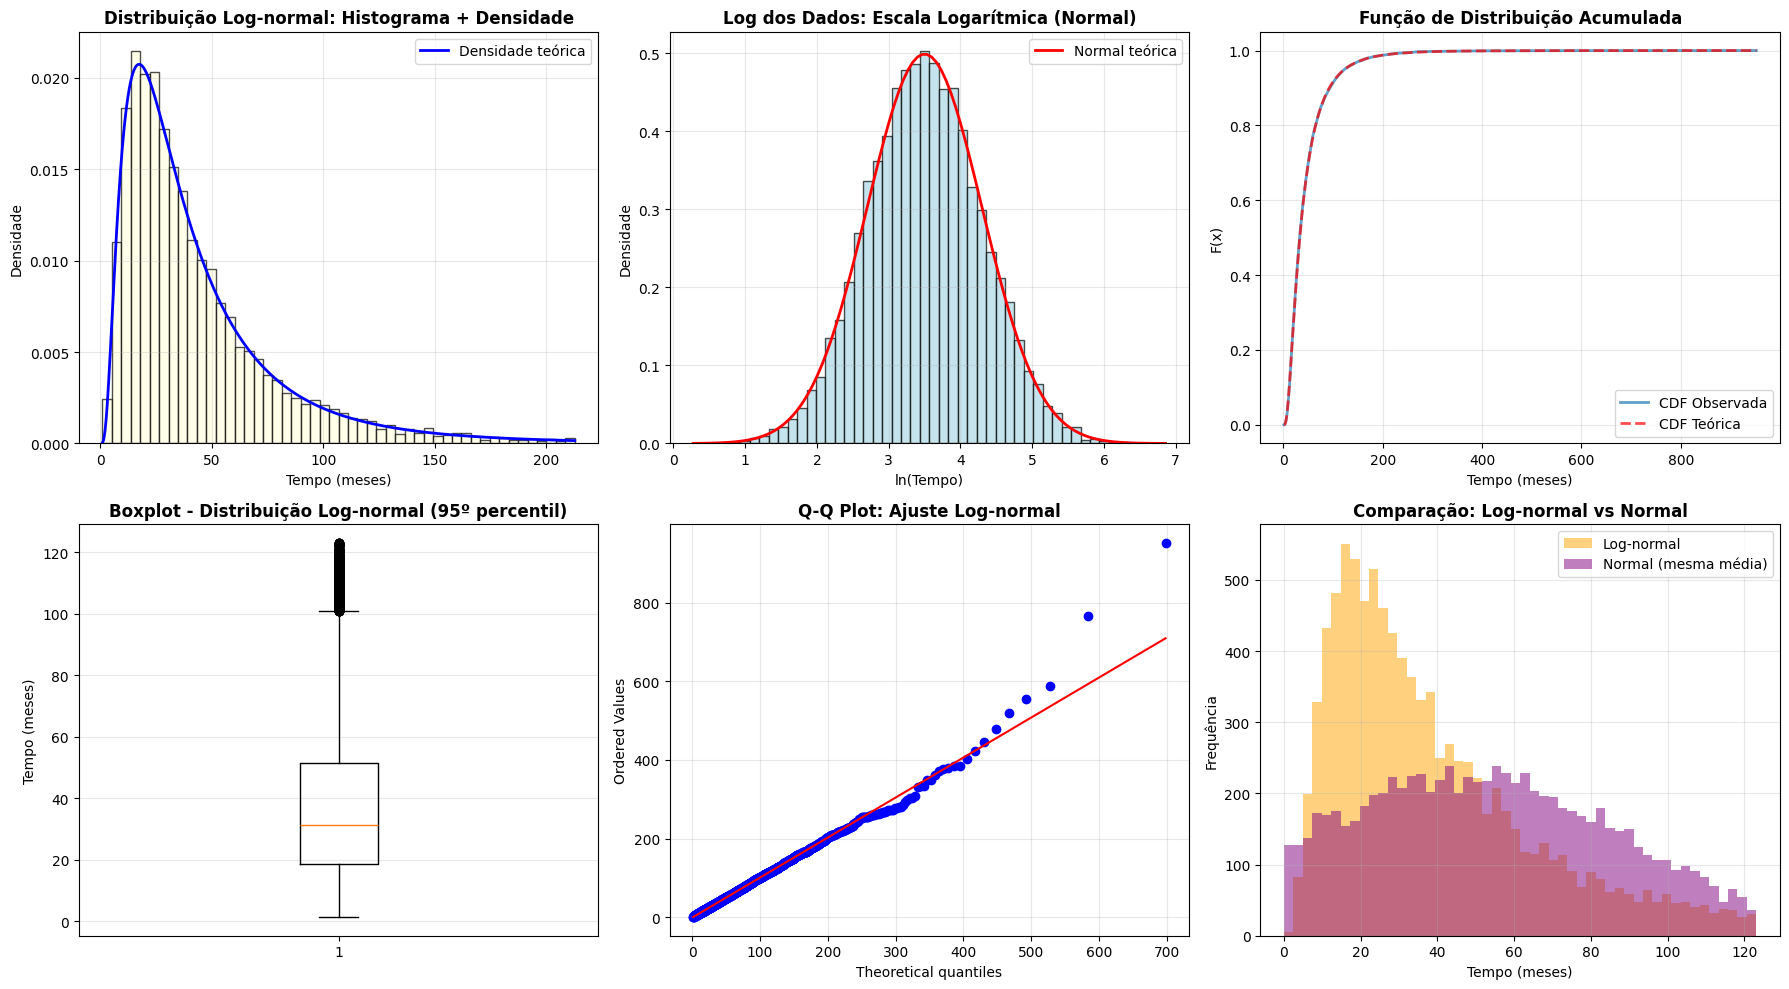

In [10]:
# Exemplo 4: Distribuição Log-normal
# Parâmetros: μ = 3.5, σ = 0.8 (tempo de progressão em meses)
mu_ln = 3.5
sigma_ln = 0.8
n_amostras = 10000

# Gerar dados da distribuição log-normal
dados_lognormal = np.random.lognormal(mu_ln, sigma_ln, n_amostras)

print("\n" + "=" * 70)
print("4. DISTRIBUIÇÃO LOG-NORMAL - Aplicação: Tempo de Progressão de Lesão")
print("=" * 70)
print(f"Parâmetros: μ = {mu_ln}, σ = {sigma_ln}")
print(f"Número de amostras: {n_amostras}")
print(f"\nEstatísticas:")
media_ln = np.exp(mu_ln + sigma_ln**2 / 2)
variancia_ln = (np.exp(sigma_ln**2) - 1) * np.exp(2*mu_ln + sigma_ln**2)
print(f"  • Média teórica (exp(μ + σ²/2)): {media_ln:.2f} meses")
print(f"  • Média observada: {np.mean(dados_lognormal):.2f} meses")
print(f"  • Desvio padrão teórico: {np.sqrt(variancia_ln):.2f} meses")
print(f"  • Desvio padrão observado: {np.std(dados_lognormal):.2f} meses")
print(f"  • Mínimo: {np.min(dados_lognormal):.2f} meses")
print(f"  • Máximo: {np.max(dados_lognormal):.2f} meses")
print(f"  • Mediana teórica (exp(μ)): {np.exp(mu_ln):.2f} meses")
print(f"  • Mediana observada: {np.median(dados_lognormal):.2f} meses")
print(f"  • Assimetria: {stats.skew(dados_lognormal):.4f}")

# Visualização
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Histograma com curva teórica
x = np.linspace(1, np.percentile(dados_lognormal, 99), 1000)
axes[0, 0].hist(dados_lognormal, bins=50, density=True, alpha=0.7, color='lightyellow', edgecolor='black', 
                range=(1, np.percentile(dados_lognormal, 99)))
axes[0, 0].plot(x, stats.lognorm.pdf(x, sigma_ln, scale=np.exp(mu_ln)), 'b-', linewidth=2, label='Densidade teórica')
axes[0, 0].set_title('Distribuição Log-normal: Histograma + Densidade', fontweight='bold')
axes[0, 0].set_xlabel('Tempo (meses)')
axes[0, 0].set_ylabel('Densidade')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Dados em escala logarítmica
dados_ln = np.log(dados_lognormal)
axes[0, 1].hist(dados_ln, bins=50, density=True, alpha=0.7, color='lightblue', edgecolor='black')
x_ln = np.linspace(np.min(dados_ln), np.max(dados_ln), 100)
axes[0, 1].plot(x_ln, stats.norm.pdf(x_ln, mu_ln, sigma_ln), 'r-', linewidth=2, label='Normal teórica')
axes[0, 1].set_title('Log dos Dados: Escala Logarítmica (Normal)', fontweight='bold')
axes[0, 1].set_xlabel('ln(Tempo)')
axes[0, 1].set_ylabel('Densidade')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# CDF teórica vs observada
sorted_data = np.sort(dados_lognormal)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
theoretical_cdf = stats.lognorm.cdf(sorted_data, sigma_ln, scale=np.exp(mu_ln))
axes[0, 2].plot(sorted_data, empirical_cdf, alpha=0.7, label='CDF Observada', linewidth=2)
axes[0, 2].plot(sorted_data, theoretical_cdf, 'r--', alpha=0.7, label='CDF Teórica', linewidth=2)
axes[0, 2].set_title('Função de Distribuição Acumulada', fontweight='bold')
axes[0, 2].set_xlabel('Tempo (meses)')
axes[0, 2].set_ylabel('F(x)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Box plot
axes[1, 0].boxplot(dados_lognormal[dados_lognormal <= np.percentile(dados_lognormal, 95)], vert=True)
axes[1, 0].set_title('Boxplot - Distribuição Log-normal (95º percentil)', fontweight='bold')
axes[1, 0].set_ylabel('Tempo (meses)')
axes[1, 0].grid(axis='y', alpha=0.3)

# Q-Q Plot (dados vs log-normal teórica)
stats.probplot(dados_lognormal, dist=stats.lognorm(s=sigma_ln, scale=np.exp(mu_ln)), plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Ajuste Log-normal', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# Comparação: Log-normal vs Normal
dados_normal_comparar = np.random.normal(media_ln, np.std(dados_lognormal), n_amostras)
axes[1, 2].hist(dados_lognormal, bins=50, alpha=0.5, label='Log-normal', color='orange', 
                range=(0, np.percentile(dados_lognormal, 95)))
axes[1, 2].hist(dados_normal_comparar, bins=50, alpha=0.5, label='Normal (mesma média)', color='purple',
                range=(0, np.percentile(dados_lognormal, 95)))
axes[1, 2].set_title('Comparação: Log-normal vs Normal', fontweight='bold')
axes[1, 2].set_xlabel('Tempo (meses)')
axes[1, 2].set_ylabel('Frequência')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **RESUMO COMPARATIVO: Distribuições Discretas vs Contínuas**

#### Tabela Resumida

In [11]:
import pandas as pd

# Criar tabela resumida das distribuições
distribuicoes_resumo = {
    'Tipo': ['Discreta', 'Discreta', 'Discreta', 'Discreta', 
             'Contínua', 'Contínua', 'Contínua', 'Contínua'],
    
    'Distribuição': ['Binomial', 'Poisson', 'Hipergeométrica', 'Multinomial',
                     'Normal', 'Exponencial', 'Uniforme', 'Log-normal'],
    
    'Parâmetros Principais': ['n, p', 'λ', 'N, K, n', 'n, p₁,...,pₖ',
                              'μ, σ', 'λ', 'a, b', 'μ, σ'],
    
    'Média': ['n*p', 'λ', 'n*K/N', 'n*pᵢ',
              'μ', '1/λ', '(a+b)/2', 'exp(μ + σ²/2)'],
    
    'Variância': ['n*p*(1-p)', 'λ', 'n*(K/N)*((N-K)/N)*((N-n)/(N-1))', 'n*pᵢ*(1-pᵢ)',
                  'σ²', '1/λ²', '(b-a)²/12', '(exp(σ²)-1)*exp(2μ+σ²)'],
    
    'Aplicação em Saúde': [
        'Taxa de realização de mamografias',
        'Casos de câncer por período',
        'Amostras positivas em lote',
        'Distribuição por faixa etária',
        'Indicadores de cobertura',
        'Tempo até próximo diagnóstico',
        'Cenários sem informação prévia',
        'Progressão de lesões pré-cancerosas'
    ]
}

df_resumo = pd.DataFrame(distribuicoes_resumo)

print("=" * 150)
print("TABELA RESUMIDA: DISTRIBUIÇÕES DISCRETAS E CONTÍNUAS")
print("=" * 150)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
print(df_resumo.to_string(index=False))
print("=" * 150)

# Características principais
print("\n" + "=" * 150)
print("CARACTERÍSTICAS PRINCIPAIS")
print("=" * 150)

print("\nDISTRIBUIÇÕES DISCRETAS:")
print("-" * 150)
print("""
1. **Binomial**: Usada para contar sucessos em n tentativas independentes
   → Quando usar: Taxa de cobertura conhecida
   
2. **Poisson**: Usada para contar eventos raros em intervalo fixo
   → Quando usar: Eventos ocorrem aleatoriamente com taxa média constante
   
3. **Hipergeométrica**: Como binomial, mas SEM reposição
   → Quando usar: Amostragem de população finita
   
4. **Multinomial**: Generalização binomial para >2 categorias
   → Quando usar: Classificação em múltiplas categorias
""")

print("\nDISTRIBUIÇÕES CONTÍNUAS:")
print("-" * 150)
print("""
1. **Normal**: Simetria perfeita, fundamental em estatística
   → Quando usar: Dados aproximadamente simétricos
   → Importância: Teorema Central do Limite
   
2. **Exponencial**: Assimétrica direita, sem memória
   → Quando usar: Tempo até evento (sobrevivência)
   → Propriedade: Falta de memória (memoryless)
   
3. **Uniforme**: Todos valores igualmente prováveis
   → Quando usar: Ausência de informação (distribuição nula)
   → Uso: Geradores de números aleatórios
   
4. **Log-normal**: Assimétrica direita, baseada em normal
   → Quando usar: Dados biológicos e naturais
   → Característica: Média > Mediana
""")

print("\n" + "=" * 150)
print("CONCLUSÕES")
print("=" * 150)
print("""
✓ Distribuições discretas são apropriadas para contagens e categorias
✓ Distribuições contínuas são apropriadas para medidas e tempos
✓ Escolher a distribuição correta é essencial para análise estatística válida
✓ Para este projeto:
  - Usar Binomial/Poisson para análise de taxa de realização de exames
  - Usar Normal/Log-normal para modelar tempos de sobrevivência
  - Usar Exponencial para tempos entre eventos
  - Usar Multinomial para distribuição por categorias (faixa etária, região)
""")

TABELA RESUMIDA: DISTRIBUIÇÕES DISCRETAS E CONTÍNUAS
    Tipo    Distribuição Parâmetros Principais         Média                       Variância                  Aplicação em Saúde
Discreta        Binomial                  n, p           n*p                       n*p*(1-p)   Taxa de realização de mamografias
Discreta         Poisson                     λ             λ                               λ         Casos de câncer por período
Discreta Hipergeométrica               N, K, n         n*K/N n*(K/N)*((N-K)/N)*((N-n)/(N-1))          Amostras positivas em lote
Discreta     Multinomial          n, p₁,...,pₖ          n*pᵢ                     n*pᵢ*(1-pᵢ)       Distribuição por faixa etária
Contínua          Normal                  μ, σ             μ                              σ²            Indicadores de cobertura
Contínua     Exponencial                     λ           1/λ                            1/λ²       Tempo até próximo diagnóstico
Contínua        Uniforme                  a,